## AML Assignment 1 - From Dirty Data to Predictive Models
Jina You

2026.02.14

Source: https://archive.ics.uci.edu/dataset/45/heart+disease

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score, cross_val_predict
# from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder, PolynomialFeatures
# from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import BernoulliNB, GaussianNB
from sklearn.linear_model import LinearRegression, LassoCV, Ridge, Lasso
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    auc,
    RocCurveDisplay,
    mean_squared_error
)

# from pprint import pprint

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_colwidth", 120)

In [3]:
!pip3 install -U ucimlrepo

In [4]:
'''
IMPORT DATA
'''

from ucimlrepo import fetch_ucirepo

# fetch dataset
heart_disease = fetch_ucirepo(id=45)

# data (as pandas dataframes)
X = heart_disease.data.features
y = heart_disease.data.targets

# metadata
print(heart_disease.metadata)

# variable information
print(heart_disease.variables)


{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [5]:
display(X.head())
display(y.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


,num
0,0
1,2
2,1
3,0
4,0


sex [1 0]
cp [1 4 3 2]
restecg [2 0 1]
exang [0 1]
thal [ 6.  3.  7. nan]
fbs [1 0]
slope [3 2 1]
ca [ 0.  3.  2.  1. nan]
num [0 2 1 3 4]


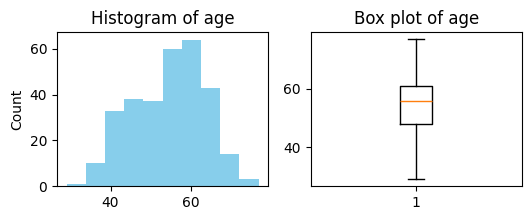

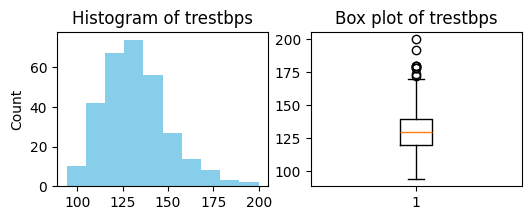

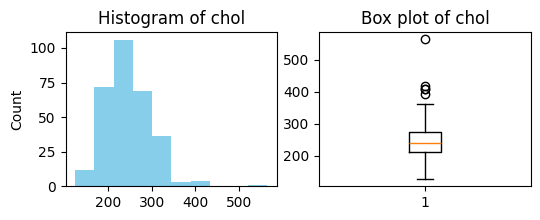

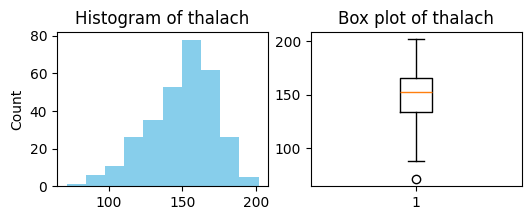

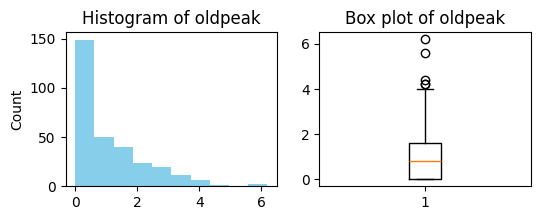

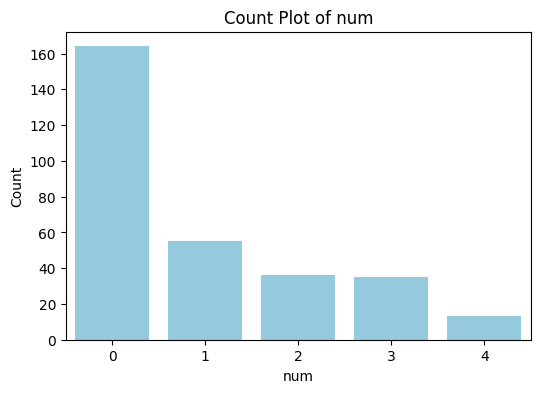

In [6]:
'''
Check Data
'''

# Separate categorical and numerical features
categorical_features_v1 = ["sex", "cp", "restecg", "exang", "thal", "fbs", "slope", "ca"]
numeric_features_v1 = ["age", "trestbps", "chol", "thalach", "oldpeak"]

# Unique values for each categorical X or y variable.
for variable in categorical_features_v1:
    print(variable, X[variable].unique())

print('num', y['num'].unique())


'''
Plot numerical features
'''

def plot_hist(data, variable):
    plt.hist(data[variable].dropna(), bins=10, color="skyblue")
    plt.title(f"Histogram of {variable}")
    plt.ylabel("Count")

def plot_count(data, variable):
    sns.countplot(x=variable, data=data, color="skyblue") # Corrected argument passing for sns.countplot
    plt.title(f"Count Plot of {variable}")
    plt.ylabel("Count")

def plot_scatter(data,variable1, variable2):
    plt.scatter(data[variable1], data[variable2])
    plt.title(f"Scatter plot of {variable1} vs {variable2}")
    plt.xlabel(variable1)
    plt.ylabel(variable2)

def plot_box(data,variable):
    plt.boxplot(data[variable])
    plt.title(f"Box plot of {variable}")

for feature in numeric_features_v1:
    plt.figure(figsize=(6,2))
    plt.subplot(1,2,1)
    plot_hist(X,feature)
    plt.subplot(1,2,2)
    plot_box(X, feature)
    plt.show()

plt.figure(figsize=(6,4))
plot_count(y,'num')
plt.show()

## IMPUTATION

In [68]:
'''
Rows with missing values
'''

print('\nRows with missing values:')
display(X[X.isna().any(axis=1)])

# Since there are only 6 rows with NA values, I dropped them.
X_dropped = X.dropna()
print('\nData shape', X.shape, '->', X_dropped.shape, 'after remving rows with nan values')


'''
Remove outlier in 'chol' variable (564)
'''

print(f'largest chol values: {sorted(X_dropped["chol"])[-3:]}')
idx = X_dropped[X_dropped['chol']==564].index
print(y.loc[idx])
# the row in data y corresponding to chol value of 574 shows that the patient didn't have a heart disease (shows a value of 0).

X_dropped = X_dropped[X_dropped['chol']< 564]
print('\nX size after removal:', X_dropped.shape)
print(f'largest chol values: {sorted(X_dropped["chol"])[-3:]}')




Rows with missing values:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
87,53,0,3,128,216,0,2,115,0,0.0,1,0.0,NaN
166,52,1,3,138,223,0,0,169,0,0.0,1,NaN,3.0
192,43,1,4,132,247,1,2,143,1,0.1,2,NaN,7.0
266,52,1,4,128,204,1,0,156,1,1.0,2,0.0,NaN
287,58,1,2,125,220,0,0,144,0,0.4,2,NaN,7.0
302,38,1,3,138,175,0,0,173,0,0.0,1,NaN,3.0



Data shape (303, 13) -> (297, 13) after remving rows with nan values
largest chol values: [409, 417, 564]
     num
152    0

X size after removal: (296, 13)
largest chol values: [407, 409, 417]


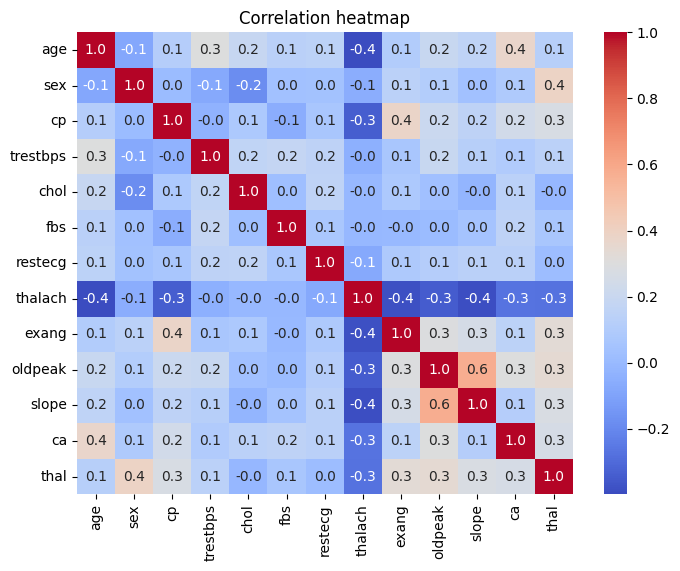

In [69]:
'''
Correlation heatmap
'''

corr = X_dropped.corr(numeric_only=True)
plt.figure(figsize=(8,6))
plt.title("Correlation heatmap")
sns.heatmap(corr, annot=True, fmt=".1f",cmap="coolwarm")
plt.show()

## Match y

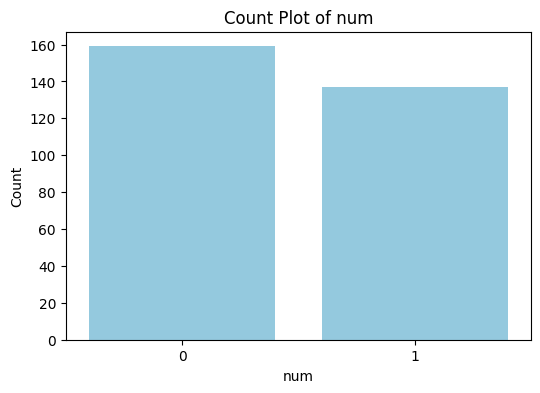

In [70]:
'''
Match size of y to X
'''

dropped_idx = X.index.difference(X_dropped.index)
y_dropped = y.drop(dropped_idx) # drop the same idx in y

X_dropped = X_dropped.reset_index(drop=True)
y_dropped = y_dropped.reset_index(drop=True)
# display(X_dropped.shape)
# display(y_dropped.shape)

'''
Convert y values from [1, 2, 3, 4] to "1".
'''

# "1" indicates presence of heart disease, "0" indicates absence
y_clean = y_dropped.copy()
y_clean['num'] = (y_clean['num'] >= 0.5).astype(int)

plt.figure(figsize=(6,4))
plot_count(y_clean, 'num')
plt.show()

# The distribution of y is pretty even

## Data Cleaning & Feature Engineering

In [72]:
'''
Feature Engineer
'''

X_clean = X_dropped.copy()


'''Age'''
# divide age into three groups: below 30, between 30 and 60, and above 60
conditions = [
    X_clean['age'] < 40,
    (X_clean['age'] >= 40) & (X_clean['age'] < 55),
    (X_clean['age'] >= 55) & (X_clean['age'] < 70),
    X_clean['age'] >= 70
]

choices = [1, 2, 3, 4]

X_clean['age'] = np.select(conditions, choices).astype(int)


'''Chol'''
conditions = [
    X_clean['chol'] < 200,
    (X_clean['chol'] >= 200) & (X_clean['chol'] < 240),
    X_clean['chol'] >= 240
]

choices = [1, 2, 3]

X_clean['chol'] = np.select(conditions, choices).astype(int)


# TRESTBPS and THALAC
X_clean['thalach_trest'] = X_clean['thalach'] / X_clean['trestbps']
X_clean.drop(columns=['thalach', 'trestbps'], inplace=True)

# # TRESTBPS
# conditions = [
#     X_clean['trestbps'] < 120,
#     (X_clean['trestbps'] >= 120) & (X_clean['trestbps'] < 130),
#     (X_clean['trestbps'] >= 130) & (X_clean['trestbps'] < 140),
#     (X_clean['trestbps'] >= 140) & (X_clean['trestbps'] < 180),
#     X_clean['trestbps'] >= 180
# ]

# choices = [1, 2, 3, 4, 5]

# X_clean['trestbps'] = np.select(conditions, choices).astype(int)


X_clean


,age,sex,cp,chol,fbs,restecg,exang,oldpeak,slope,ca,thal,thalach_trest
0,3,1,1,2,1,2,0,2.3,3,0.0,6.0,1.034483
1,3,1,4,3,0,2,1,1.5,2,3.0,3.0,0.675000
2,3,1,4,2,0,2,1,2.6,2,2.0,7.0,1.075000
3,1,1,3,3,0,0,0,3.5,3,0.0,3.0,1.438462
4,2,0,2,2,0,2,0,1.4,1,0.0,3.0,1.323077
...,...,...,...,...,...,...,...,...,...,...,...,...
291,3,0,4,3,0,0,1,0.2,2,0.0,7.0,0.878571
292,2,1,1,3,0,0,0,1.2,2,0.0,7.0,1.200000
293,3,1,4,1,1,0,0,3.4,2,2.0,7.0,0.979167
294,3,1,4,1,0,0,1,1.2,2,1.0,7.0,0.884615


## Feature Importance

In [81]:
model = LinearRegression()
model.fit(X_train, y_train)

coefficients = pd.Series(model.coef_[0], index=X_clean.columns)
coefficients.abs().sort_values(ascending=False)

,0
thalach_trest,0.246041
exang,0.167223
sex,0.136353
ca,0.122928
fbs,0.095406
cp,0.087368
slope,0.062889
thal,0.061936
chol,0.050424
restecg,0.038373


## Train Model

In [74]:
'''
Preprocessing
'''

# version 2: test. included ordered variables in numeric features  (1. ca, 2. slope, 3. fbs)
categorical_features_v2 = ["sex", "cp", "restecg", "exang", "thal"]
numeric_features_v2 = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca", "slope", "fbs"]

# version 3: after feature engineering
categorical_features_v3 = ["sex", "cp", "restecg", "exang", "thal", "age", "ca", "slope", "fbs", 'chol']
numeric_features_v3 = ["thalach", "trestbps", "oldpeak"]

# version 4: after feature engineering
categorical_features_v4 = ["sex", "cp", "restecg", "exang", "thal", "age", "ca", "slope", "fbs", 'chol']
numeric_features_v4 = ["thalach_trest", "oldpeak"]

numeric_features = numeric_features_v4
categorical_features = categorical_features_v4
all_features = numeric_features + categorical_features

categorical_pipeline = Pipeline([("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
numeric_pipeline = Pipeline([
    # ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])


'''
Model Training
'''

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.25, stratify=y_clean, random_state=RANDOM_STATE)

# Train Gaussian NB
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
y_hat_nb = nb_model.predict(X_train)

# Train Linear Regression
lr_model = Pipeline(steps=[('preprocessor', preprocessor),('classifier', LinearRegression())])
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
y_hat_lr = lr_model.predict(X_train)

# Train Lasso Regression
lasso_model = Pipeline(steps=[('preprocessor', preprocessor),('classifier', Lasso(alpha=0.05))])
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)
y_hat_lasso = lasso_model.predict(X_train)

# Train Ridge Regression
ridge_model = Pipeline(steps=[('preprocessor', preprocessor),('classifier', Ridge(alpha=0.05))])
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)
y_hat_ridge = ridge_model.predict(X_train)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


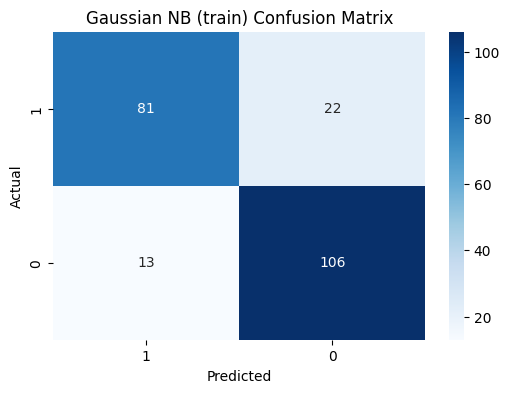

Gaussian NB (train): Accuracy=0.8423 | Precision=0.8617 | Recall=0.7864 | F1-score=0.8223



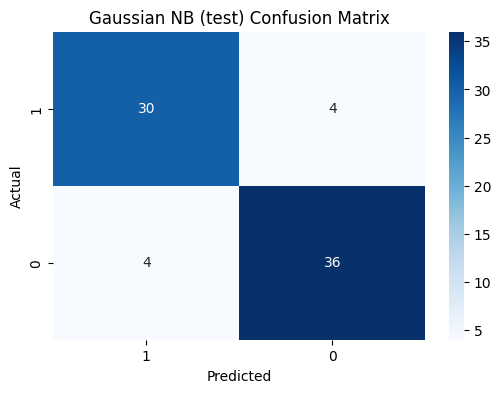

Gaussian NB (test): Accuracy=0.8919 | Precision=0.8824 | Recall=0.8824 | F1-score=0.8824



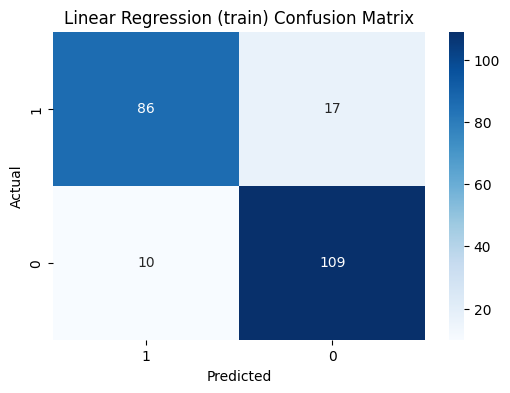

Linear Regression (train): Accuracy=0.8784 | Precision=0.8958 | Recall=0.8350 | F1-score=0.8643



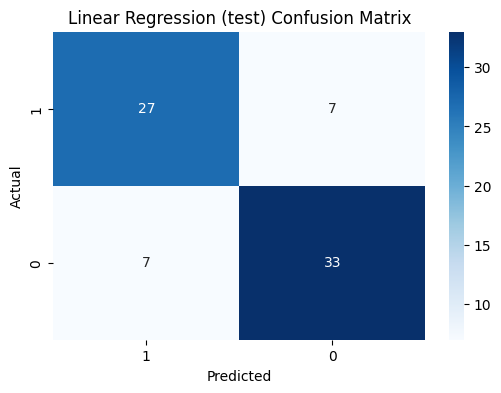

Linear Regression (test): Accuracy=0.8108 | Precision=0.7941 | Recall=0.7941 | F1-score=0.7941
Lasso Regression (train): Accuracy=0.8423 | Precision=0.8953 | Recall=0.7476 | F1-score=0.8148
Lasso Regression (test): Accuracy=0.8649 | Precision=0.9000 | Recall=0.7941 | F1-score=0.8438
Ridge Regression (train): Accuracy=0.8784 | Precision=0.8958 | Recall=0.8350 | F1-score=0.8643
Ridge Regression (test): Accuracy=0.8108 | Precision=0.7941 | Recall=0.7941 | F1-score=0.7941


(0.8108108108108109,
 0.7941176470588235,
 0.7941176470588235,
 0.7941176470588235)

In [93]:
'''
Evaluate Models
'''

def evaluate_model(y_test, y_pred, threshold, name, graph_cm ="yes"):

    y_pred = (y_pred > threshold).astype(int) # doesn't matter for Gaussian NB

    # Classification Report
    report = classification_report(y_test, y_pred)
    # print(f"\n {name} Classification Report:\n", report)

    # Confusion Matrix Plot
    if graph_cm == "yes":
        print('')
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(6,4))
        ax = sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        ax.invert_xaxis()
        ax.invert_yaxis()
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title(f"{name} Confusion Matrix")
        # plt.savefig(f"{name}_confusion_matrix.png", dpi=300, bbox_inches="tight")
        plt.show()

    # Evaluation Metrics (one by one)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    print(f'{name}: Accuracy={acc:.4f} | Precision={prec:.4f} | Recall={rec:.4f} | F1-score={f1:.4f}')

    # with open(f"{name}_evaluation.txt", "w") as file:
    #     file.write(f"{name} Classification Report:\n")
    #     file.write(report)
    #     file.write(f'Accuracy={acc:.4f} | Precision={prec:.4f} | Recall={rec:.4f} | F1-score={f1:.4f}')

    return acc, prec, rec, f1




threshold = 0.5
graph_cm = "yes"

# Gaussian NB
evaluate_model(y_train, y_hat_nb, threshold, 'Gaussian NB (train)', graph_cm)
evaluate_model(y_test, y_pred_nb, threshold, 'Gaussian NB (test)', graph_cm)

# Linear Regression
evaluate_model(y_train, y_hat_lr, threshold, 'Linear Regression (train)', graph_cm)
evaluate_model(y_test, y_pred_lr, threshold, 'Linear Regression (test)', graph_cm)

# Ridge and Lasso Regressions
graph_cm = "no"

evaluate_model(y_train, y_hat_lasso, threshold, 'Lasso Regression (train)', graph_cm)
evaluate_model(y_test, y_pred_lasso, threshold, 'Lasso Regression (test)', graph_cm)

evaluate_model(y_train, y_hat_ridge, threshold, 'Ridge Regression (train)', graph_cm)
evaluate_model(y_test, y_pred_ridge, threshold, 'Ridge Regression (test)', graph_cm)




## AUC and Classification Thresholds

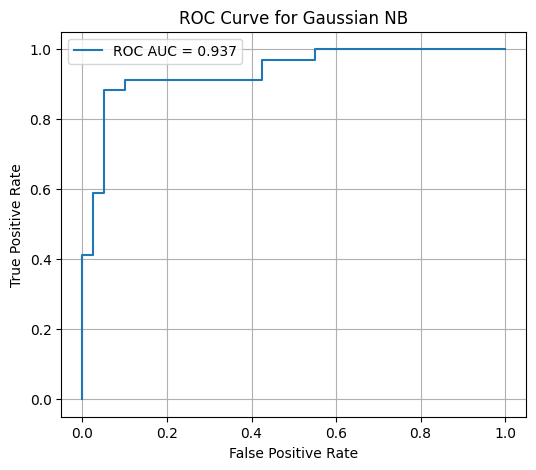

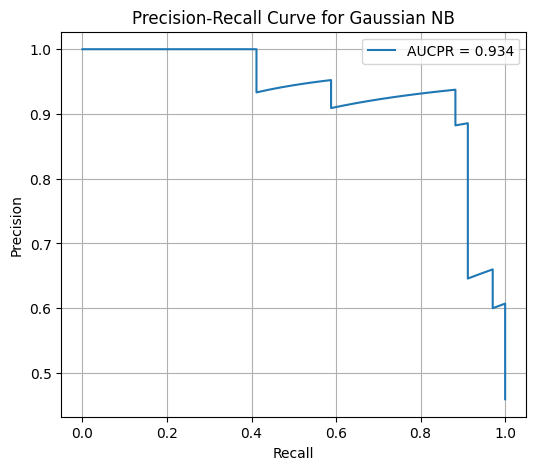

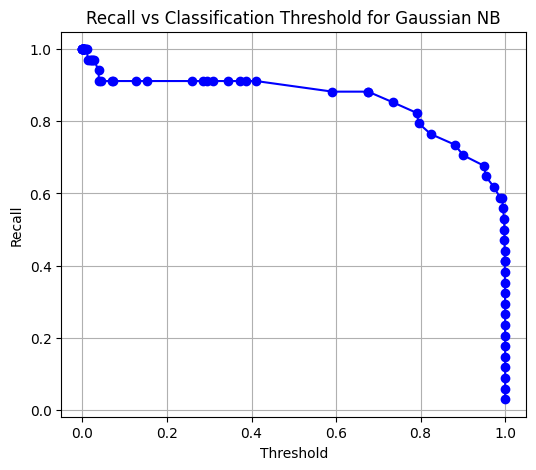

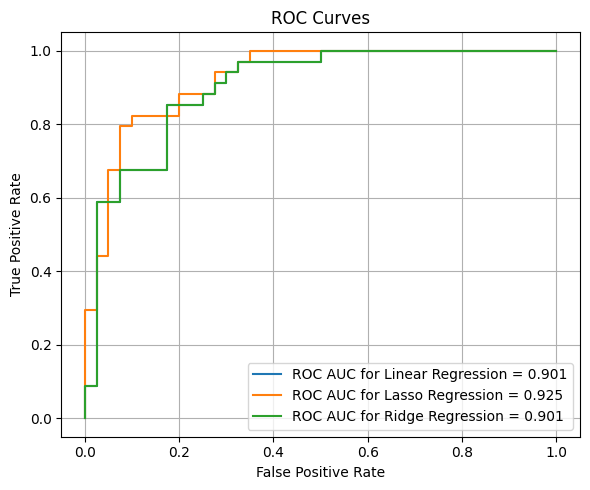

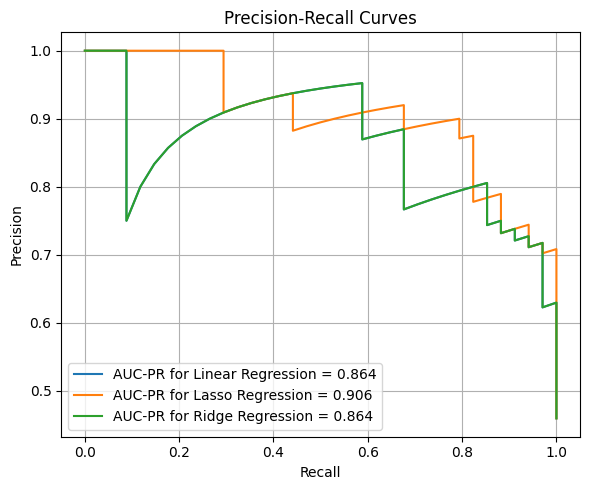

In [65]:
'''
Plot AUC
'''

'''Gaussian NB'''
def plot_roc(model, name):

    y_scores = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_scores)
    fpr, tpr, _ = roc_curve(y_test, y_scores)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve for {name}")
    plt.legend()
    plt.grid(True)
    plt.show()

    return


def plot_pr(model, name):

    y_scores = model.predict_proba(X_test)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
    ap_score = average_precision_score(y_test, y_scores)

    plt.figure(figsize=(6,5))
    plt.plot(recall, precision, label=f"AUCPR = {ap_score:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve for {name}")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(6,5))
    plt.plot(thresholds, recall[:-1], color='blue', marker='o')  # drop last recall
    plt.xlabel('Threshold')
    plt.ylabel('Recall')
    plt.title(f'Recall vs Classification Threshold for {name}')
    plt.grid(True)
    plt.show()

    return


plot_roc(nb_model, 'Gaussian NB')
plot_pr(nb_model, 'Gaussian NB')


'''Regressions'''
def plot_roc_regressions(y_pred, name):
    fpr, tpr, _ = roc_curve(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)

    plt.plot(fpr, tpr, label=f"ROC AUC for {name} = {roc_auc:.3f}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves")
    return

plt.figure(figsize=(6,5))
plot_roc_regressions(y_pred_lr, 'Linear Regression')
plot_roc_regressions(y_pred_lasso, 'Lasso Regression')
plot_roc_regressions(y_pred_ridge, 'Ridge Regression')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


def plot_pr_regressions(y_pred, name):
    precision, recall, _ = precision_recall_curve(y_test, y_pred)
    pr_auc = average_precision_score(y_test, y_pred)

    plt.plot(recall, precision, label=f"AUC-PR for {name} = {pr_auc:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curves")
    return

plt.figure(figsize=(6,5))
plot_pr_regressions(y_pred_lr, 'Linear Regression')
plot_pr_regressions(y_pred_lasso, 'Lasso Regression')
plot_pr_regressions(y_pred_ridge, 'Ridge Regression')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


threshold =  0.3
Lasso Regression (test): Accuracy=0.7027 | Precision=0.6071 | Recall=1.0000 | F1-score=0.7556
Ridge Regression (test): Accuracy=0.8108 | Precision=0.7174 | Recall=0.9706 | F1-score=0.8250

threshold =  0.4
Lasso Regression (test): Accuracy=0.8243 | Precision=0.7442 | Recall=0.9412 | F1-score=0.8312
Ridge Regression (test): Accuracy=0.7973 | Precision=0.7317 | Recall=0.8824 | F1-score=0.8000

threshold =  0.5
Lasso Regression (test): Accuracy=0.8649 | Precision=0.9000 | Recall=0.7941 | F1-score=0.8438
Ridge Regression (test): Accuracy=0.8108 | Precision=0.7941 | Recall=0.7941 | F1-score=0.7941

threshold =  0.6
Lasso Regression (test): Accuracy=0.7973 | Precision=0.9130 | Recall=0.6176 | F1-score=0.7368
Ridge Regression (test): Accuracy=0.7973 | Precision=0.8519 | Recall=0.6765 | F1-score=0.7541

threshold =  0.7
Lasso Regression (test): Accuracy=0.7297 | Precision=0.9375 | Recall=0.4412 | F1-score=0.6000
Ridge Regression (test): Accuracy=0.7838 | Precision=0.9500 | Re

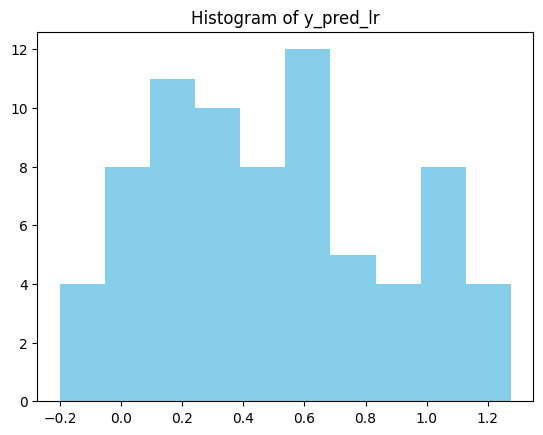

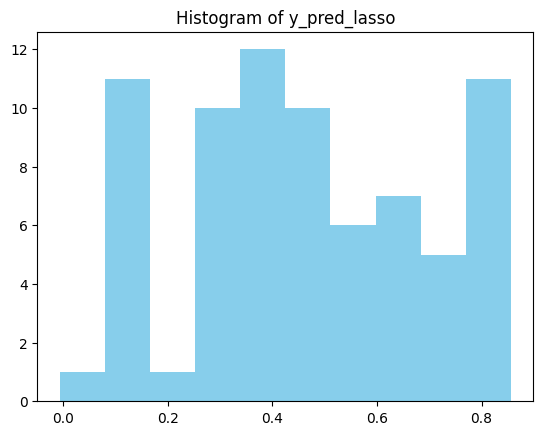

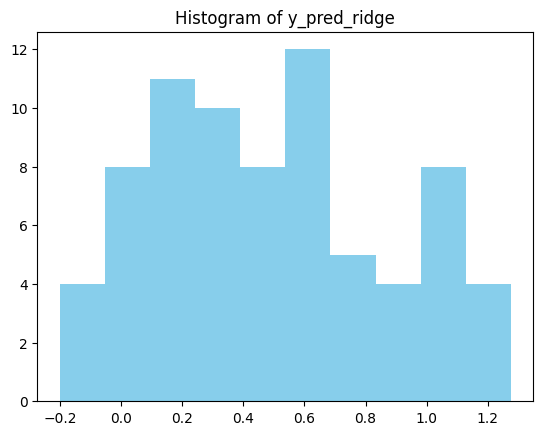

In [79]:
'''
Testing Threshold
'''

# Train Lasso Regression
lasso_model = Pipeline(steps=[('preprocessor', preprocessor),('classifier', Lasso(alpha=a))])
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)
y_hat_lasso = lasso_model.predict(X_train)

# Train Ridge Regression
ridge_model = Pipeline(steps=[('preprocessor', preprocessor),('classifier', Ridge(alpha=a))])
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)
y_hat_ridge = ridge_model.predict(X_train)

# Evaluate
graph_cm = "no"
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
  print('\nthreshold = ', threshold)
  evaluate_model(y_test, y_pred_lasso, threshold, 'Lasso Regression (test)', graph_cm)
  evaluate_model(y_test, y_pred_ridge, threshold, 'Ridge Regression (test)', graph_cm)

plt.hist(y_pred_lr, bins=10, color="skyblue")
plt.title('Histogram of y_pred_lr')
plt.show()
plt.hist(y_pred_lasso, bins=10, color="skyblue")
plt.title('Histogram of y_pred_lasso')
plt.show()
plt.hist(y_pred_ridge, bins=10, color="skyblue")
plt.title('Histogram of y_pred_ridge')
plt.show()

## Experimenting with Alphas

In [77]:
'''
Experimenting with different alphas for Linear and Ridge regressions smoothing
'''

alphas = [0.01, 0.05, 0.1, 0.2, 0.5]

for a in alphas:
    print('\nalpha', a, '\n')

    # Train Lasso Regression
    lasso_model = Pipeline(steps=[('preprocessor', preprocessor),('classifier', Lasso(alpha=a))])
    lasso_model.fit(X_train, y_train)
    y_pred_lasso = lasso_model.predict(X_test)
    y_hat_lasso = lasso_model.predict(X_train)

    # Train Ridge Regression
    ridge_model = Pipeline(steps=[('preprocessor', preprocessor),('classifier', Ridge(alpha=a))])
    ridge_model.fit(X_train, y_train)
    y_pred_ridge = ridge_model.predict(X_test)
    y_hat_ridge = ridge_model.predict(X_train)

    # Evaluate

    graph_cm = "no"

    evaluate_model(y_train, y_hat_lasso, threshold, 'Lasso Regression (train)', graph_cm)
    evaluate_model(y_test, y_pred_lasso, threshold, 'Lasso Regression (test)', graph_cm)

    evaluate_model(y_train, y_hat_ridge, threshold, 'Ridge Regression (train)', graph_cm)
    evaluate_model(y_test, y_pred_ridge, threshold, 'Ridge Regression (test)', graph_cm)



# Will use a = 0.05 going forward.
a = 0.05



alpha 0.01 

Lasso Regression (train): Accuracy=0.8694 | Precision=0.8776 | Recall=0.8350 | F1-score=0.8557
Lasso Regression (test): Accuracy=0.8108 | Precision=0.7941 | Recall=0.7941 | F1-score=0.7941
Ridge Regression (train): Accuracy=0.8784 | Precision=0.8958 | Recall=0.8350 | F1-score=0.8643
Ridge Regression (test): Accuracy=0.8108 | Precision=0.7941 | Recall=0.7941 | F1-score=0.7941

alpha 0.05 

Lasso Regression (train): Accuracy=0.8423 | Precision=0.8953 | Recall=0.7476 | F1-score=0.8148
Lasso Regression (test): Accuracy=0.8649 | Precision=0.9000 | Recall=0.7941 | F1-score=0.8438
Ridge Regression (train): Accuracy=0.8784 | Precision=0.8958 | Recall=0.8350 | F1-score=0.8643
Ridge Regression (test): Accuracy=0.8108 | Precision=0.7941 | Recall=0.7941 | F1-score=0.7941

alpha 0.1 

Lasso Regression (train): Accuracy=0.7568 | Precision=0.8356 | Recall=0.5922 | F1-score=0.6932
Lasso Regression (test): Accuracy=0.7838 | Precision=0.8214 | Recall=0.6765 | F1-score=0.7419
Ridge Regressi

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

Ridge Regression (test): Accuracy=0.8108 | Precision=0.7941 | Recall=0.7941 | F1-score=0.7941

alpha 0.5 

Lasso Regression (train): Accuracy=0.5360 | Precision=0.0000 | Recall=0.0000 | F1-score=0.0000
Lasso Regression (test): Accuracy=0.5405 | Precision=0.0000 | Recall=0.0000 | F1-score=0.0000
Ridge Regression (train): Accuracy=0.8784 | Precision=0.8958 | Recall=0.8350 | F1-score=0.8643
Ridge Regression (test): Accuracy=0.8108 | Precision=0.7941 | Recall=0.7941 | F1-score=0.7941


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



alpha 1e-07 

Gaussian NB w Smoothing (train): Accuracy=0.8378 | Precision=0.8317 | Recall=0.8155 | F1-score=0.8235
Gaussian NB w Smoothing (test): Accuracy=0.8243 | Precision=0.8182 | Recall=0.7941 | F1-score=0.8060

alpha 1e-05 

Gaussian NB w Smoothing (train): Accuracy=0.8378 | Precision=0.8317 | Recall=0.8155 | F1-score=0.8235
Gaussian NB w Smoothing (test): Accuracy=0.8243 | Precision=0.8182 | Recall=0.7941 | F1-score=0.8060

alpha 0.001 



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Gaussian NB w Smoothing (train): Accuracy=0.8378 | Precision=0.8317 | Recall=0.8155 | F1-score=0.8235
Gaussian NB w Smoothing (test): Accuracy=0.8243 | Precision=0.8182 | Recall=0.7941 | F1-score=0.8060

alpha 0.1 

Gaussian NB w Smoothing (train): Accuracy=0.8514 | Precision=0.8571 | Recall=0.8155 | F1-score=0.8358
Gaussian NB w Smoothing (test): Accuracy=0.8378 | Precision=0.8235 | Recall=0.8235 | F1-score=0.8235

alpha 1 

Gaussian NB w Smoothing (train): Accuracy=0.8423 | Precision=0.8864 | Recall=0.7573 | F1-score=0.8168


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Gaussian NB w Smoothing (test): Accuracy=0.8378 | Precision=0.8235 | Recall=0.8235 | F1-score=0.8235


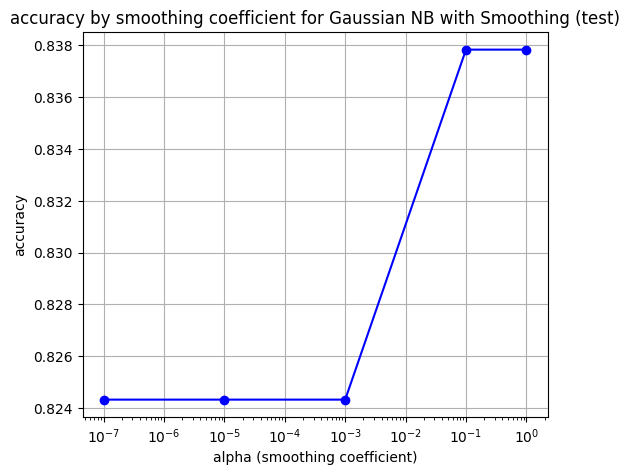

In [58]:
'''
Experimenting with different var smoothing coefficient for Gaussian NB
'''

alphas = [1e-7, 1e-5, 1e-3, 0.1, 1]
accs = []
precs = []
recs = []
f1s = []

for a in alphas:
    print('\nalpha', a, '\n')

    # Train Gaussian NB w Smoothing
    nb_smooth = Pipeline(steps=[('preprocessor', preprocessor),('classifier', GaussianNB(var_smoothing=a))])
    nb_smooth.fit(X_train, y_train)
    y_pred_smoothnb = nb_smooth.predict(X_test)
    y_hat_smoothnb = nb_smooth.predict(X_train)

    # Evaluate
    graph_cm = "no"
    acc, prec, rec, f1 = evaluate_model(y_train, y_hat_smoothnb, threshold, 'Gaussian NB w Smoothing (train)', graph_cm)

    acc, prec, rec, f1 = evaluate_model(y_test, y_pred_smoothnb, threshold, 'Gaussian NB w Smoothing (test)', graph_cm)
    accs.append(acc)
    precs.append(prec)
    recs.append(rec)
    f1s.append(f1)

plt.figure(figsize=(6,5))
plt.semilogx(alphas, accs, color='blue', marker='o')  # drop last recall
plt.xlabel('alpha (smoothing coefficient)')
plt.ylabel('accuracy')
plt.title(f'accuracy by smoothing coefficient for Gaussian NB with Smoothing (test)')
plt.grid(True)
plt.show()

# Didn't see much difference from var_smoothing

**Delete Below**

In [40]:

    # def scale_numeric_features(X):
    #     X_scaled = X.copy()
    #     for variable in numeric_features:
    #         X_scaled[f'{variable}_scaled'] = scaler.fit_transform(X_scaled[[variable]])
    #         X_scaled.drop(columns=[variable], inplace=True)
    #     return X_scaled

    # X_train_scaled = scale_numeric_features(X_train)
    # X_test_scaled = scale_numeric_features(X_test)




    # Cross Validation - Accuracy
    k = 3
    kf = KFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)
    lr_scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='accuracy')

    print(f"Cross Validation Accuracy: {lr_scores.mean():.4f}")




    # Accuracy Cross Validation
    k = 3
    kf = KFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)

    scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='accuracy') # HOW TO SCALE ONLY NUMERICAL FEATURES

    print("Cross Validation Accuracy:", scores.mean())







# ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
# for feature in categorical_features: # or non_ordered_categorical_features
#     encoded = ohe.fit_transform(X_clean[[feature]])
#     encoded_df = pd.DataFrame(encoded, columns=[f"{feature}={c}" for c in ohe.categories_[0]])
#     X_clean = X_clean.merge(encoded_df, left_index=True, right_index=True)
#     X_clean.drop(columns=[feature], inplace=True)

a = 2
model = Ridge(alpha=a)
model = Lasso(alpha=a, max_iter=10000)

NameError: name 'model' is not defined